## model definition

prenorm + rope + swiglu with weight tying for the embed / unembed matrix

use vanilla mha since using grouped mqa or mqa is unnecessary for the scale of this exercise and we aren't doing kv cached inference.

config:

D=256
F=4*256
L=10
N=4
=> ~10.5M params

In [1]:
from dataclasses import dataclass
from flax import nnx

@dataclass
class MoEConfig:
  experts_per_token: int
  experts: int

@dataclass
class ModelConfig:
  hidden_size: int
  ffw_size: int
  layers: int
  attn_heads: int
  vocab_size: int
  moe_config: MoEConfig | None

  def size(self, *, active=True):
      attn_params = 4*self.hidden_size**2 + self.hidden_size
      if not self.moe_config:
          mlp_params = 3*self.hidden_size*self.ffw_size + self.hidden_size + self.ffw_size
      else:
          k = self.moe_config.experts_per_token if active else self.moe_config.experts
          mlp_params = 3*self.hidden_size*self.ffw_size*k + self.hidden_size + self.ffw_size
      return self.layers*(attn_params + mlp_params) + self.vocab_size*self.hidden_size


class RMSNorm(nnx.Module):
  def __init__(self, config):
    hidden_size = config.hidden_size
    self.gamma = nnx.Param(jnp.ones((hidden_size,)))

  def __call__(self, x):
    inv_norm = jax.lax.rsqrt(jnp.mean(x**2, axis=-1) + 1e-6)[..., None]
    return self.gamma * x * inv_norm


class RoPE(nnx.Module):
  def _create_inv_freqs(self, base, head_size):
    assert head_size % 2 == 0
    inds = jnp.arange(head_size // 2)
    return base ** (-2 * inds / head_size)

  def _create_cos_sin(self, T, inv_freqs):
    # [1, T, 1, 1]
    positions = jnp.arange(T)[None, :, None, None]
    # [1, 1, 1, H]
    dupl_inv_freqs = jnp.concat([inv_freqs, inv_freqs])[None, None, None, :]
    # [1, T, 1, H]
    freqs = positions * dupl_inv_freqs
    return jnp.cos(freqs), jnp.sin(freqs)

  def _rotate_half(self, x):
    # x[B, T, N, H]
    H = x.shape[-1]
    even = jax.lax.dynamic_slice_in_dim(x, 0, H//2, axis=-1)
    odd = jax.lax.dynamic_slice_in_dim(x, H//2, H//2, axis=-1)
    return jnp.concat([-odd, even], axis=-1)

  def __init__(self, config, base=10_000):
    """

    for each pair of features in input

    x = [[x0],
        [x1]]

    apply rotation matrix:

    R = [[cos0, -sin0]
        [sin0, cos0]]

    Rx =>

    x0' = x0*cos0 - x1*sin0
    x1' = x1*cos0 + x0*sin0

    where 0 = 2*pi*f_j*t

    and f_j = base ** (-2i/d) where i is the index of the pair

    (at i = 0, we have frequency 1 (fast recurrences))
    (at i = d/2, we have frequency base (slow long term))

    pretend top half of x are "even" indices of x
    and bottom half of x are "odd" indices of x
    this doesn't matter since the score doesn't change
    and is just a permutation in projection weights


    x_even' = x_even*cos0 - x_odd*sin0
    x_odd' = x_odd*cos0 + x_even*sin0

    x is split so that top half is even and bottom half is odd

    then this essentially becomes x = x * cos + rotate_half(x) * sin
    where rotate half takes the odd and stacks on top and negates

    note the d dimension of cos and sin must follow this half convention as well
    """
    head_size = config.hidden_size // config.attn_heads
    self.base = base
    self.inv_freqs = self._create_inv_freqs(base, head_size)

  def __call__(self, x):
    """
    pretend top half of x are "even" indices of x
    and bottom half of x are "odd" indices of x
    this doesn't matter since the score doesn't change
    and is just a permutation in projection weights
    """

    B, T, N, H = x.shape
    cos, sin = self._create_cos_sin(T, self.inv_freqs)
    return x * cos + self._rotate_half(x) * sin


class MHA(nnx.Module):
  def __init__(self, config, *, rngs):
    self.config = config
    hidden_size = config.hidden_size
    self.pre_norm = RMSNorm(config)
    self.rope = RoPE(config)
    self.qkv_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, 3 * hidden_size)))
    self.o_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, hidden_size)))

  def _sdpa(self, q, k, v):
    """
    q[B, T, N, H]
    k[B, S, N, H]
    v[B, S, N, H]
    """
    B, T, N, H = q.shape
    S = k.shape[1]
    logits = jnp.einsum('btnh,bsnh->btsn', q, k)
    scaled_logits = (H ** -0.5) * logits
    # logits[B, T, S, N]
    # mask[1, T, S, 1]
    # non mask token positions are True
    mask = jnp.tril(jnp.ones((T, S), dtype=jnp.bool))[None, :, :, None]
    # [B, T, S, N]
    masked_scaled_logits = jnp.where(mask, scaled_logits, -jnp.inf)
    weights = jax.nn.softmax(masked_scaled_logits, axis=2)
    attn_out = jnp.einsum('btsn,bsnh->btnh', weights, v)
    return attn_out

  def __call__(self, x):
    # x = [B, T, D]
    B, T, D = x.shape
    N = self.config.attn_heads
    H = D//N
    t = self.pre_norm(x)
    qkv = jnp.einsum('btd,df->btf', t, self.qkv_proj)
    # q[B, T, D]
    q = jax.lax.dynamic_slice_in_dim(qkv, 0, D, axis=-1).reshape((B, T, N, H))
    q = self.rope(q)
    k = jax.lax.dynamic_slice_in_dim(qkv, D, D, axis=-1).reshape((B, T, N, H))
    k = self.rope(k)
    v = jax.lax.dynamic_slice_in_dim(qkv, 2*D, D, axis=-1).reshape((B, T, N, H))
    # [B, T, N, H] -> [B, T, D]
    attn_out = self._sdpa(q, k, v).reshape((B, T, D))
    out = jnp.einsum('btd,df->btf', attn_out, self.o_proj)
    return x + out


class MLP(nnx.Module):
  def __init__(self, config, *, rngs):
    self.config = config
    hidden_size = config.hidden_size
    ffw_size = config.ffw_size
    moe_config = config.moe_config
    self.pre_norm = RMSNorm(config)
    if moe_config:
      E, k = moe_config.experts, moe_config.experts_per_token
      self.router = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, E)))
      self.glu_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (E, hidden_size, 2*ffw_size)))
      self.down_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (E, ffw_size, hidden_size)))
    else:
      self.glu_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, 2*ffw_size)))
      self.down_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (ffw_size, hidden_size)))
    self.beta = nnx.Param(jnp.ones(ffw_size))



  def __call__(self, x):
    moe_config = self.config.moe_config
    # x[B, T, D]
    # [D, 2F]
    ffw_size = self.config.ffw_size
    t = self.pre_norm(x)

    """
    MoE:
    one router for all 3 proj matrices in matrix
    router: [D, E], softmax and do weighted sum
    glu: [E, D, 2F]
    down_proj: [E, F, D]

    get top k experts for each token:
    [B, T, k]

    flatten router experts into [B*T, k]

    create inds of size [B*T, k] (repeated over k axis)
    flatten into [B*T*k]
    flatten router experts into [B*T*k]
    sort router experts into [B*T*k]
    create group sizes
    create flattened sortened input of [B*T*k, D]
    use ragged dot
    unsort input into [B*T*k, D]
    reshape to [B, T, k, D]
    multiply by expert weights and sum

    flatten input to [B*T, k]

    """


    if moe_config:
      k, E = moe_config.experts_per_token, moe_config.experts
      # [B, T, E]
      router_logits = jnp.einsum('btd,de->bte', t, self.router)
      # [B, T, E]
      router_weights = jax.nn.softmax(router_logits, axis=-1)
      # [B, T, k] [B, T, k]
      top_k_weights, top_k_experts = jax.lax.top_k(router_weights, k)

      B, T, D = t.shape
      # [B * T, D]
      flattened_x = t.reshape((B*T, D))
      # [B * T, k]
      flattened_x_inds_padded = jnp.repeat(jnp.arange(B*T)[:, None], k, axis=-1)
      # [B*T*k]
      flattened_x_inds_padded = flattened_x_inds_padded.reshape((B*T*k,))
      # [B*T*k]
      flattened_routed_experts = top_k_experts.reshape((B*T*k,))
      # [B*T*k]
      # inds has indices from 0 to B*T*k since it returns sorted inds
      sorted_routed_experts_inds = jnp.argsort(flattened_routed_experts)
      # [B*T*k]
      # sorted_routed_experts = flattened_routed_experts[sorted_routed_experts_inds]
      # [E]
      sizes = jnp.bincount(flattened_routed_experts, minlength=E, length=E)


      # [B*T*k]
      # sorted x inds relative to the experts arrays sorted by expert (which token does which expert route correspond to)
      sorted_flattened_x_inds = flattened_x_inds_padded[sorted_routed_experts_inds]
      # [B*T*k, D]
      # x sorted by expert
      sorted_flat_x = flattened_x[sorted_flattened_x_inds]
      # x[B*T*k, D]
      # W[E, D, 2F]
      # => [B*T*k, 2F]
      glu = jax.lax.ragged_dot(sorted_flat_x, self.glu_proj.value, sizes)
      # [B*T*k, F]
      f1 = jax.lax.dynamic_slice_in_dim(glu, 0, ffw_size, axis=-1)
      # [B*T*k, F]
      f2 = jax.lax.dynamic_slice_in_dim(glu, ffw_size, ffw_size, axis=-1)
      # [B*T*k, F]
      swiglu_out = f1 * f2 * jax.nn.sigmoid(self.beta * f2)
      # [B*T*k, D]
      # each token is still in sorted order
      out = jax.lax.ragged_dot(swiglu_out, self.down_proj.value, sizes)
      # [B*T*k, D]
      out = out[jnp.argsort(sorted_routed_experts_inds)]
      # [B, T, k, D]
      out = out.reshape((B, T, k, D))
      # w[B, T, k] -> [B, T, k, 1]
      # out[B, T, k, D]
      # => [B, T, k, D] => [B, T, D]
      out = jnp.sum(top_k_weights[..., None] * out, axis=2)

      # return sizes and router probs: [E, ], [E]
      total = B * T
      f = sizes / total
      p = jnp.sum(router_weights, axis=[0, 1]) / total
      return x + out, p, f
    else:
      glu = jnp.einsum('btd,df->btf', t, self.glu_proj)
      # [B, T, F]
      f1 = jax.lax.dynamic_slice_in_dim(glu, 0, ffw_size, axis=-1)
      # [B, T, F]
      f2 = jax.lax.dynamic_slice_in_dim(glu, ffw_size, ffw_size, axis=-1)
      t = f1 * f2 * jax.nn.sigmoid(self.beta * f2)
      out = jnp.einsum('btf,fd->btd', t, self.down_proj)
      return x + out


class TransformerLayer(nnx.Module):
  def __init__(self, config, *, rngs):
    self.attn_block = MHA(config, rngs=rngs)
    self.mlp_block = MLP(config, rngs=rngs)

  def __call__(self, x):
    t = self.attn_block(x)
    return self.mlp_block(t)


class Transformer(nnx.Module):
  def __init__(self, config, *, rngs):
    hidden_size = config.hidden_size
    vocab_size = config.vocab_size
    self.is_moe = config.moe_config is not None
    self.embed = nnx.Param(0.02 * jax.random.normal(rngs.params(), (vocab_size, hidden_size)))
    self.layers = [TransformerLayer(config, rngs=rngs) for _ in range(config.layers)]

  def __call__(self, x):
    x = self.embed[x]
    ps = []
    fs = []
    for l in self.layers:
      if self.is_moe:
        x, p, f = l(x)
        ps.append(p)
        fs.append(f)
      else:
        x = l(x)

    logits = jnp.einsum('btd,vd->btv', x, self.embed)
    if self.is_moe:
      return logits, jnp.vstack(ps), jnp.vstack(fs)

    return logits

In [ ]:
import numpy as np
import jax.numpy as jnp
import jax


class NaiveMoEMLP(nnx.Module):
    def __init__(self, config, pre_norm, router, glu_proj, down_proj, beta):
      self.config = config
      self.pre_norm = pre_norm
      self.router = router
      self.glu_proj = glu_proj
      self.down_proj = down_proj
      self.beta = beta

    def __call__(self, x):
        """
        router: [D, E]
        glu_proj: [E, D, 2F]
        down_proj: [E, F, D]
        beta: [F]

        x: [B, T, D]
        """
        k = self.config.moe_config.experts_per_token
        x_n = self.pre_norm(x)
        E, F, D = self.down_proj.value.shape
        B, T, D = x.shape
        # [B, T, E]
        router_logits = jnp.einsum('btd,de->bte', x_n, self.router)
        # [B, T, E]
        router_weights = jax.nn.softmax(router_logits, axis=-1)
        # [B, T, k] [B, T, k]
        top_k_weights, top_k_experts = jax.lax.top_k(router_weights, k)

        out = jnp.zeros((B, T, D))
        for b in range(B):
            for t in range(T):
                # [D]
                tok = x_n[b, t]
                # [k]
                top_k = top_k_experts[b, t]
                # [k, D, 2F]
                k_glu_proj = self.glu_proj[top_k]
                # [k, 2F]
                glu = jnp.einsum('d,kdf->kf', tok, k_glu_proj)
                # [k, F]
                f1 = jax.lax.dynamic_slice_in_dim(glu, 0, F, axis=-1)
                # [k, F]
                f2 = jax.lax.dynamic_slice_in_dim(glu, F, F, axis=-1)
                # [k, F]
                tmp = f1 * f2 * jax.nn.sigmoid(self.beta * f2)
                # [k, F, D]
                k_down_proj = self.down_proj[top_k]
                # [k, D]
                tmp = jnp.einsum('kf,kfd->kd', tmp, k_down_proj)
                # [k]
                k_weights = top_k_weights[b, t]
                # [k, 1] * [k, D] = [k, D] => [D]
                tok_out = jnp.sum(k_weights[:, None] * tmp, axis=0)
                out = out.at[b, t].set(tok_out)

        return x + out


B, T, D, F, k, E = 2, 2, 4, 16, 2, 4

moe_config = MoEConfig(
  experts_per_token=k,
  experts=E
)

config = ModelConfig(
  hidden_size=D,
  ffw_size=F,
  layers=2,
  attn_heads=2,
  vocab_size=3,
  moe_config=moe_config
)

rngs = nnx.Rngs(0)
moe_mlp = MLP(config, rngs=rngs)
moe_naive = NaiveMoEMLP(config, moe_mlp.pre_norm, moe_mlp.router, moe_mlp.glu_proj, moe_mlp.down_proj, moe_mlp.beta)
x = jax.random.normal(rngs.params(), (B, T, D))
moe_out, _, _ = moe_mlp(x)
moe_baseline = moe_naive(x)

print('moe_out shape:', moe_out.shape)
print('moe_baseline shape:', moe_baseline.shape)

np.testing.assert_array_almost_equal(moe_out, moe_baseline)

KeyboardInterrupt: 

## basic training loop

config:

D=256
F=4*256
L=10
N=4
=> ~10.5M params

In [2]:
import jax
import jax.numpy as jnp
import optax
from optax.losses import softmax_cross_entropy_with_integer_labels as softmax_ce_loss
import functools
import dataclasses

# do batch generation ENTIRELY on device, can then be jit into training step and no cpu -> accel comm!

"""

with a key:

return seq => [MAX_SEQ_LEN] (where end is padded), valid_mask

alg idea:

ex: 3 + 32 = 35

- generate ops = [3, 32]
- split into digits with res

digits = [[0, 0, 3],
          [0, 3, 2],
          [0, 3, 5]]

ops_res = [3, 32, 35]

ops shape => [3, 1]
mults = [-2, -1, 0]
mults shape => [1, 3]

# [1, 3] * [3, 1] => [3, 3]
digits = 10**mults * ops_res % 10


e3_mask = digits[0, :] > 0
e2_mask = jnp.logical_or(e3_mask, digits[1, :] > 0)
e1_mask = jnp.logical_or(e2_mask, digits[2, :] > 0)

rest of alg:
- construct full seq
- add extra dim to write to at the end for masked tokens
- use mask to create inds
- set inds, cut off last padding elem and return


Note: to make the task harder, spaces are randomly assigned to surround + and =
"""

MAX_OPERAND = 999
SPACE = 10
PLUS = 11
EQUAL = 12
EOS = 13
MAX_SEQ_LEN = 17

def gen_seq(key):
    key, op_key, space_key = jax.random.split(key, 3)
    ops = jax.random.choice(op_key, MAX_OPERAND, shape=(2,))
    ops_res = jnp.concat([ops, jnp.sum(ops, keepdims=True)])
    mults = 10**(jnp.array([-3.0, -2.0, -1.0, 0.0]))[None, :]
    digits = (mults * ops_res[:, None]).astype(jnp.int16) % 10
    e3_mask = digits[:, 0:1] > 0
    e2_mask = jnp.logical_or(e3_mask, digits[:, 1:2] > 0)
    e1_mask = jnp.logical_or(e2_mask, digits[:, 2:3] > 0)
    digits_mask = jnp.concat([
        e3_mask,
        e2_mask,
        e1_mask,
        jnp.array([True, True, True]).reshape((3, 1))
    ], axis=-1)
    spaces_mask = jax.random.choice(space_key, 2, shape=(4,)).astype(jnp.bool)
    full_seq = jnp.concat([
        digits[0],
        jnp.array([SPACE]),
        jnp.array([PLUS]),
        jnp.array([SPACE]),
        digits[1],
        jnp.array([SPACE]),
        jnp.array([EQUAL]),
        jnp.array([SPACE]),
        digits[2],
        jnp.array([EOS])
    ])
    full_seq_mask = jnp.concat([
        digits_mask[0],
        spaces_mask[0].reshape((1,)),
        jnp.array([True]),
        spaces_mask[1].reshape((1,)),
        digits_mask[1],
        spaces_mask[2].reshape((1,)),
        jnp.array([True]),
        spaces_mask[3].reshape((1,)),
        digits_mask[2],
        jnp.array([True])
    ])
    seq = jnp.full(MAX_SEQ_LEN+1, SPACE)
    inds = jnp.cumsum(full_seq_mask.astype(jnp.int8)) - 1
    inds = jnp.where(full_seq_mask, inds, -1)
    seq = seq.at[inds].set(full_seq)
    seq = seq[:MAX_SEQ_LEN]

    prompt_len = jnp.sum(e2_mask[:-1, :].astype(jnp.int8)) + jnp.sum(e1_mask[:-1, :].astype(jnp.int8)) + 2 + 2 + jnp.sum(spaces_mask.astype(jnp.int8))
    t = jnp.arange(MAX_SEQ_LEN-1)
    valid_loss_mask = jnp.logical_and(
        t >= prompt_len - 1,
        t < full_seq_mask.astype(jnp.int8).sum() - 1
    )
    return seq, valid_loss_mask


def gen_batch(bs, key):
    return jax.vmap(gen_seq)(jax.random.split(key, bs))


def decode(enc_arr):
    a = []
    for i in enc_arr.tolist():
        if i == SPACE:
            a.append(' ')
        elif i == PLUS:
            a.append('+')
        elif i == EQUAL:
            a.append('=')
        elif i == EOS:
            a.append('<|EOS|>')
        else:
            a.append(str(i))

    return "".join(a)


# reuse input state buffer so we're not storing 2x model+opt state unnecessarily
@functools.partial(jax.jit, donate_argnums=(0,), static_argnames=('bs', 'n', 'load_bal_alpha'))
def scan(state, graphdef, key, n, bs, load_bal_alpha):
    def f(carry, _):
        state, key = carry
        model, opt = nnx.merge(graphdef, state)
        key, subkey = jax.random.split(key)
        batch, loss_mask = gen_batch(bs, subkey)
        def loss_fn(model):
            if load_bal_alpha:
                logits, ps, fs = model(batch[:, :-1])
                # ps: [L, E]
                E = ps.shape[-1]
                load_balancing_loss = load_bal_alpha * E * jnp.sum(ps * fs)
            else:
                logits = model(batch[:, :-1])
                load_balancing_loss = jnp.array(0.0)
            labels = batch[:, 1:]
            losses = softmax_ce_loss(logits, labels)
            m = loss_mask.astype(jnp.int8)
            ce_loss = jnp.sum(m * losses) / jnp.sum(m)
            return ce_loss + load_balancing_loss, (ce_loss, load_balancing_loss)

        loss, grads = nnx.value_and_grad(loss_fn, has_aux=True)(model)
        opt.update(model, grads)
        _, state = nnx.split((model, opt))
        return (state, key), loss

    carry, losses = jax.lax.scan(f, (state, key), length=n)
    state, _ = carry
    return state, losses


def train_n_steps(model, opt, bs, n, key, load_bal_alpha):
    graphdef, state = nnx.split((model, opt))
    state, losses = scan(state, graphdef, key, n, bs, load_bal_alpha)
    nnx.update((model, opt), state)
    return losses


@dataclass
class TrainingConfig:
    max_lr: float
    min_lr: float
    steps: int
    flops: int
    warmup_steps: int
    bs: int
    seed: int
    print_every: int
    load_bal_alpha: float
    chunk_size: int = 100


def train_model(model_config, training_config):
    rngs = nnx.Rngs(params=training_config.seed, batch=training_config.seed+1)
    model = Transformer(model_config, rngs=rngs)
    lr_schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=training_config.max_lr,
        warmup_steps=training_config.warmup_steps,
        decay_steps=training_config.steps - training_config.warmup_steps,
        end_value=training_config.min_lr
    )
    opt = nnx.Optimizer(model, optax.adamw(learning_rate=lr_schedule), wrt=nnx.Param)
    chunks = int(training_config.steps // training_config.chunk_size)
    # want exact FLOPS as counted and don't want to recompile with a different n
    assert training_config.steps % training_config.chunk_size == 0
    assert training_config.print_every % training_config.chunk_size == 0
    losses = []
    ce_losses = []
    aux_losses = []

    print(f'--- starting run for model of size {model_config.size():1.2e} ---')
    for c in range(chunks):
        losses_jnp, losses_split_jnp = train_n_steps(
            model,
            opt,
            training_config.bs,
            training_config.chunk_size,
            rngs.batch(),
            training_config.load_bal_alpha
        )
        ce_losses_jnp, aux_losses_jnp = losses_split_jnp
        losses.extend(losses_jnp.tolist())
        if model_config.moe_config:
            ce_losses.extend(ce_losses_jnp.tolist())
            aux_losses.extend(aux_losses_jnp.tolist())

        step = (c+1)*training_config.chunk_size
        if step % training_config.print_every == 0:
          print(f'step: {step}, loss: {losses[-1]}')

    if model_config.moe_config:
        return losses, ce_losses, aux_losses
    else:
        return losses

## preliminary runs
run a subset of different model sizes to see at what point their loss hits close to 0 (the problem has been completely solved) to choose appropriate C horizon lengths for Chinchilla laws

In [3]:
import matplotlib.pyplot as plt
import numpy as np


def flops_to_training_steps(model_size, flops_horizon, bs, t):
    flops_per_step = 6 * model_size * bs * t
    return int(flops_horizon // flops_per_step)


def training_steps_to_flops(model_size, training_steps, bs, t):
    flops_per_step = 6 * model_size * bs * t
    return int(flops_per_step * training_steps)


def round_training_steps_to_chunk_size(model_size, chunk_size, ideal_flops, bs, t):
    steps = flops_to_training_steps(model_size, ideal_flops, bs, t)
    rounded_steps = int((steps + chunk_size - 1) // chunk_size) * chunk_size
    return rounded_steps, training_steps_to_flops(model_size, rounded_steps, bs, t)


def build_training_configs(model_configs, chunk_size, bs, flops_horizon, load_bal_alpha, print_every=100):
    t_configs = []
    for m in model_configs:
        steps, flops = round_training_steps_to_chunk_size(
            m.size(),
            chunk_size,
            flops_horizon,
            bs,
            MAX_SEQ_LEN
        )
        print(f'model size: {m.size():1.2e} training for flops: {flops:1.2e} and steps: {steps}')
        t_configs.append(
            TrainingConfig(
                max_lr=1e-3,
                min_lr=1e-4,
                steps=steps,
                flops=flops,
                warmup_steps=int(0.05*steps),
                bs=bs,
                seed=42,
                chunk_size=chunk_size,
                print_every=print_every,
                load_bal_alpha=load_bal_alpha
            )
        )

    return t_configs


def train_models(
        model_configs,
        training_configs,
        *,
        folder=None
):
    run_losses = []
    run_ce_losses = []
    run_aux_losses = []
    for i in range(len(training_configs)):
        model_config = model_configs[i]
        training_config = training_configs[i]
        if model_config.moe_config:
            losses, ce_losses, aux_losses = (np.array(j) for j in train_model(model_config, training_config))
            run_ce_losses.append(ce_losses)
            run_aux_losses.append(aux_losses)
        else:
            losses = np.array(train_model(model_config, training_config))
        run_losses.append(losses)
        # save results to file
        if folder:
            with open(f'{folder}/size_{model_config.size():1.2e}_flops_{training_config.flops:1.2e}.npy', 'wb') as f:
                np.save(f, losses)
                if model_config.moe_config:
                    np.save(f, ce_losses)
                    np.save(f, aux_losses)

    if model_configs[0].moe_config:
        return run_losses, run_ce_losses, run_aux_losses
    else:
        return run_losses


def plot_losses(
        model_configs,
        training_configs,
        losses,
        *,
        f_name=None,
        extra=None
):
    fig, ax = plt.subplots()
    horizon = None
    for i in range(len(training_configs)):
        m = model_configs[i]
        t = training_configs[i]
        if not horizon:
            horizon = t.flops
        size = m.size()
        flops_per_step = int(6 * m.size() * t.bs * MAX_SEQ_LEN)
        x = flops_per_step * (np.arange(t.steps) + 1)
        run_losses = losses[i]
        ax.plot(x, run_losses, label=f'{size:1.2e}')

    ax.set_xlabel('flops')
    ax.set_ylabel('loss')
    if extra:
        ax.set_title(f'Training runs over {horizon:1.0e} flops, {extra}')
    else:
        ax.set_title(f'Training runs over {horizon:1.0e} flops')
    ax.legend()
    if f_name:
        fig.savefig(f_name)


MODEL_CONFIGS = [
    # 4.4K
    ModelConfig(
        hidden_size=16,
        ffw_size=4*16,
        layers=1,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # 8K
    ModelConfig(
        hidden_size=16,
        ffw_size=4*16,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # ~19K
    ModelConfig(
        hidden_size=24,
        ffw_size=4*24,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # 33.6K
    ModelConfig(
        hidden_size=32,
        ffw_size=4*32,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # 66.8K
    ModelConfig(
        hidden_size=32,
        ffw_size=4*32,
        layers=4,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # ~150K
    ModelConfig(
        hidden_size=48,
        ffw_size=4*48,
        layers=4,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),
]


model size: 4.42e+03 training for flops: 1.00e+11 and steps: 13880
model size: 8.61e+03 training for flops: 1.00e+11 and steps: 7120
model size: 1.91e+04 training for flops: 1.00e+11 and steps: 3220
model size: 3.36e+04 training for flops: 1.00e+11 and steps: 1830
model size: 6.68e+04 training for flops: 1.00e+11 and steps: 920
model size: 1.49e+05 training for flops: 9.99e+10 and steps: 410
--- starting run for model of size 4.42e+03 ---
step: 100, loss: 2.637756824493408
step: 200, loss: 2.3612329959869385
step: 300, loss: 2.2273998260498047
step: 400, loss: 2.059682846069336
step: 500, loss: 1.960489273071289
step: 600, loss: 1.7953213453292847
step: 700, loss: 1.8101776838302612
step: 800, loss: 1.6904103755950928
step: 900, loss: 1.747205138206482
step: 1000, loss: 1.8681437969207764
step: 1100, loss: 1.8997108936309814
step: 1200, loss: 1.6422617435455322
step: 1300, loss: 1.6240233182907104
step: 1400, loss: 1.6196328401565552
step: 1500, loss: 1.6231440305709839
step: 1600, los

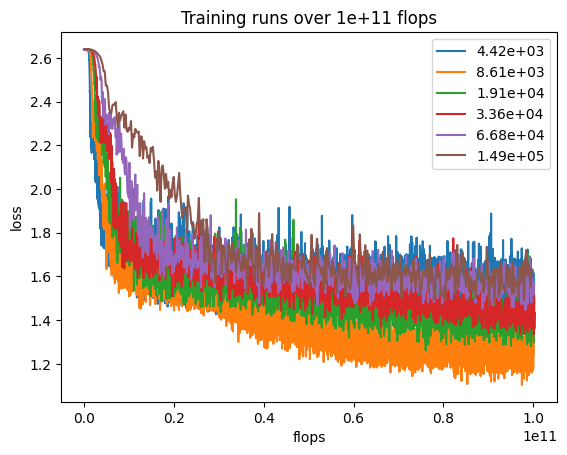

In [3]:
FLOPS_HORIZON = 1e11
CHUNK_SIZE = 10
BS = 16
FLOPS_HORIZON = 1e11
preliminary_training_configs = build_training_configs(MODEL_CONFIGS, CHUNK_SIZE, BS, FLOPS_HORIZON)
losses = train_models(MODEL_CONFIGS, preliminary_training_configs)
plot_losses(MODEL_CONFIGS, preliminary_training_configs, losses, f_name=f'prelim_{FLOPS_HORIZON:1.0e}')

model size: 4.42e+03 training for flops: 1.00e+13 and steps: 1387600
model size: 8.61e+03 training for flops: 1.00e+13 and steps: 711900
model size: 1.91e+04 training for flops: 1.00e+13 and steps: 321600
model size: 3.36e+04 training for flops: 1.00e+13 and steps: 182400
model size: 6.68e+04 training for flops: 1.00e+13 and steps: 91800
model size: 1.49e+05 training for flops: 1.00e+13 and steps: 41100
--- starting run for model of size 4.42e+03 ---
step: 1000, loss: 2.637132167816162
step: 2000, loss: 2.3162200450897217
step: 3000, loss: 2.201467990875244
step: 4000, loss: 2.0322396755218506
step: 5000, loss: 1.982460379600525
step: 6000, loss: 1.809226155281067
step: 7000, loss: 1.9276710748672485
step: 8000, loss: 1.7536661624908447
step: 9000, loss: 1.679547905921936
step: 10000, loss: 1.6092827320098877
step: 11000, loss: 1.728966474533081
step: 12000, loss: 1.5958375930786133
step: 13000, loss: 1.6343538761138916
step: 14000, loss: 1.5979822874069214
step: 15000, loss: 1.5339493

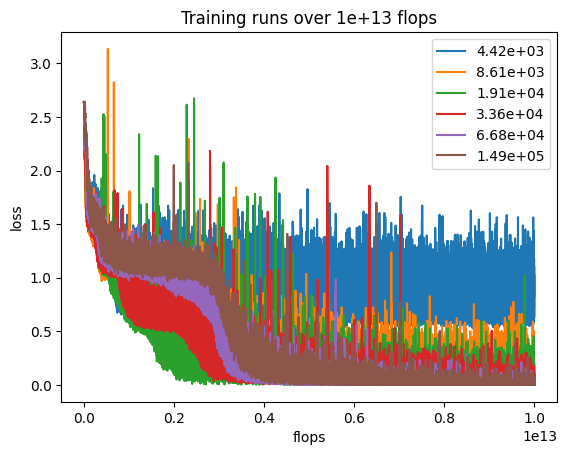

In [15]:
FLOPS_HORIZON = 1e13
CHUNK_SIZE = 100
preliminary_training_configs = build_training_configs(MODEL_CONFIGS, CHUNK_SIZE, BS, FLOPS_HORIZON, 1000)
losses = train_models(MODEL_CONFIGS, preliminary_training_configs)
plot_losses(MODEL_CONFIGS, preliminary_training_configs, losses, f_name=f'prelim_{FLOPS_HORIZON:1.0e}')

## Create grid of runs to use for Chinchilla scaling law approaches

In [4]:
# two decades of compute from 1e11 to 1e13
FLOP_HORIZONS = [int(1e11*(2.5119**i)) for i in range(6)]

for f in FLOP_HORIZONS:
    print(f'{f:1.2e}')


def build_grid_training_configs(model_configs, flop_horizons, chunk_size, bs, load_bal_alpha=0.0):
    return [
        build_training_configs(
            model_configs,
            chunk_size,
            bs,
            horizon,
            load_bal_alpha,
            1000
        )
        for horizon in flop_horizons
   ]


CHUNK_SIZE = 10
BS = 16
TRAINING_CONFIGS = build_grid_training_configs(
    MODEL_CONFIGS,
    FLOP_HORIZONS,
    CHUNK_SIZE,
    BS
)


# FLOP_HORIZONS x MODEL_CONFIGS
def train_grid(
        model_configs,
        training_configs,
        *,
        folder='grid'
):
    is_moe = bool(model_configs[0].moe_config)
    loss_grid = []
    ce_loss_grid = []
    aux_loss_grid = []
    for i in range(len(training_configs)):
        l = train_models(
            model_configs,
            training_configs[i],
            folder=folder
        )
        if is_moe:
            losses, ce_losses, aux_losses = l
            loss_grid.append(losses)
            ce_loss_grid.append(ce_losses)
            aux_loss_grid.append(aux_losses)
        else:
            loss_grid.append(l)

    if is_moe:
        return loss_grid, ce_loss_grid, aux_loss_grid
    return loss_grid

1.00e+11
2.51e+11
6.31e+11
1.58e+12
3.98e+12
1.00e+13
model size: 4.42e+03 training for flops: 1.00e+11 and steps: 13880
model size: 8.61e+03 training for flops: 1.00e+11 and steps: 7120
model size: 1.91e+04 training for flops: 1.00e+11 and steps: 3220
model size: 3.36e+04 training for flops: 1.00e+11 and steps: 1830
model size: 6.68e+04 training for flops: 1.00e+11 and steps: 920
model size: 1.49e+05 training for flops: 9.99e+10 and steps: 410
model size: 4.42e+03 training for flops: 2.51e+11 and steps: 34860
model size: 8.61e+03 training for flops: 2.51e+11 and steps: 17880
model size: 1.91e+04 training for flops: 2.51e+11 and steps: 8080
model size: 3.36e+04 training for flops: 2.51e+11 and steps: 4580
model size: 6.68e+04 training for flops: 2.52e+11 and steps: 2310
model size: 1.49e+05 training for flops: 2.53e+11 and steps: 1040
model size: 4.42e+03 training for flops: 6.31e+11 and steps: 87550
model size: 8.61e+03 training for flops: 6.31e+11 and steps: 44920
model size: 1.91e+0

In [ ]:
# compute loss grid from scratch
loss_grid = train_grid(MODEL_CONFIGS, TRAINING_CONFIGS)

In [23]:
# load loss grid from disk
def load_loss_grid_from_disk(model_configs, training_configs, *, folder='grid'):
    loss_grid = []
    ce_loss_grid = []
    aux_loss_grid = []
    is_moe = bool(model_configs[0].moe_config)
    for ts in training_configs:
        losses_at_c = []
        ce_losses_at_c = []
        aux_losses_at_c = []
        for i in range(len(model_configs)):
            t = ts[i]
            m = model_configs[i]
            with open(folder + f'/size_{m.size():1.2e}_flops_{t.flops:1.2e}.npy', 'rb') as f:
                losses = np.load(f)
                assert losses.shape[0] == t.steps
                if is_moe:
                    ce_losses = np.load(f)
                    aux_losses = np.load(f)
                    ce_losses_at_c.append(ce_losses)
                    aux_losses_at_c.append(aux_losses)
                losses_at_c.append(losses)
        loss_grid.append(losses_at_c)
        ce_loss_grid.append(ce_losses_at_c)
        aux_loss_grid.append(aux_losses_at_c)
    if is_moe:
        return loss_grid, ce_loss_grid, aux_loss_grid
    return loss_grid

IndentationError: expected an indented block after 'if' statement on line 26 (415532920.py, line 27)

In [ ]:
loss_grid = load_loss_grid_from_disk(MODEL_CONFIGS, TRAINING_CONFIGS)

In [6]:
import numpy as np

def gaussian_smooth(arr: np.ndarray, sigma):
    radius = int(3*sigma)
    inds = np.arange(-radius, radius+1)
    kernel = np.exp(-(inds**2)/(2*(sigma**2)))
    # symmetrical
    kernel = kernel / np.sum(kernel)
    padded_arr = np.pad(arr, (radius, radius), constant_values=(arr[0], arr[-1]))
    return np.convolve(padded_arr, kernel, mode='valid')


# visually verify gaussian smoothing window
# for h_i in range(len(TRAINING_CONFIGS)):
#     for m_i in range(2):
#         m = MODEL_CONFIGS[m_i]
#         t = TRAINING_CONFIGS[h_i][m_i]
#         losses = loss_grid[h_i][m_i]
#         sigma = t.steps // 100
#         smoothed_losses = gaussian_smooth(losses, sigma)
#         plot_losses([m], [t], [losses])
#         plot_losses([m], [t], [smoothed_losses], extra='smoothed')

In [7]:
# smooth losses
def smooth_loss_grid(model_configs, training_configs, loss_grid):
    smoothed_loss_grid = []
    for ts_i in range(len(training_configs)):
        tmp = []
        for m_i in range(len(model_configs)):
            losses = loss_grid[ts_i][m_i]
            t = training_configs[ts_i][m_i]
            smoothed_losses = gaussian_smooth(losses, t.steps // 100)
            tmp.append(smoothed_losses)
        smoothed_loss_grid.append(tmp)
    return smoothed_loss_grid

In [ ]:
smoothed_loss_grid = smooth_loss_grid(MODEL_CONFIGS, TRAINING_CONFIGS, loss_grid)

In [8]:
# exclude flop budgets that had multiple runs that saturated (ambiguous)
def filter_saturated_runs(model_configs, training_configs, flop_horizons, smoothed_loss_grid):
    smoothed_valid_loss_grid = []
    valid_training_configs = []
    valid_flop_horizons = []
    SATURATION_THRESHOLD = 2e-2
    for ts_i in range(len(training_configs)):
        saturated_ct = 0
        for m_i in range(len(model_configs)):
            smoothed_losses = smoothed_loss_grid[ts_i][m_i]
            t = training_configs[ts_i][m_i]
            tail_window = smoothed_losses[-int(0.01*t.steps):]
            if np.median(tail_window) <= SATURATION_THRESHOLD:
                saturated_ct += 1

        if saturated_ct <= 1:
            smoothed_valid_loss_grid.append(smoothed_loss_grid[ts_i])
            valid_training_configs.append(training_configs[ts_i])
            valid_flop_horizons.append(flop_horizons[ts_i])

    return smoothed_valid_loss_grid, valid_training_configs, valid_flop_horizons

In [ ]:
smoothed_valid_loss_grid, valid_training_configs, valid_flop_horizons = filter_saturated_runs(
    MODEL_CONFIGS,
    TRAINING_CONFIGS,
    FLOP_HORIZONS,
    smoothed_loss_grid
)


for f in valid_flop_horizons:
    print(f'VALID FLOP HORIZON: {f:1.2e}')

## Chinchilla Laws (Dense Model) - Approach 1: Fix model sizes and vary number of training tokens

In [9]:
class TrainingRunTailInterp:
    def __init__(self, model_size, bs, flops_range, smoothed_tail):
        self.model_size = model_size
        self.smoothed_tail = smoothed_tail
        self.flops_per_step = 6 * model_size * bs * MAX_SEQ_LEN
        self.flops_range = flops_range


    def covers(self, flops):
        return self.flops_range[0] <= flops <= self.flops_range[1]


    def interp_loss(self, flops):
        # get continuous mapping of C -> loss
        x = (np.arange(len(self.smoothed_tail)) * self.flops_per_step) + self.flops_range[0]
        return np.interp(flops, x, self.smoothed_tail)


def build_interpolants(model_configs, training_configs, smooth_loss_grid, tail_range=0.15):
    interpolants = []
    for ts_i in range(len(training_configs)):
        for m_i in range(len(model_configs)):
            m = model_configs[m_i]
            t = training_configs[ts_i][m_i]
            smooth_losses = smooth_loss_grid[ts_i][m_i]
            start_i = int(smooth_losses.shape[0]*(1-tail_range))
            flops_per_step = 6 * m.size() * t.bs * MAX_SEQ_LEN
            flops_range = (int(flops_per_step*start_i), t.flops)
            smoothed_tail = smooth_losses[start_i:]
            interpolants.append(
                TrainingRunTailInterp(
                    model_size=m.size(),
                    bs=t.bs,
                    flops_range=flops_range,
                    smoothed_tail=smoothed_tail
                )
            )

    return interpolants


@dataclass
class OptPoint:
    n_opt: int
    d_opt: int
    c: float


def fit_power_laws(opt_pts):
    ln_c = np.log(np.array([pt.c for pt in opt_pts])).reshape((-1, 1))
    x = np.hstack([ln_c, np.ones(ln_c.shape)])

    ln_n_opt = np.log(np.array([pt.n_opt for pt in opt_pts])).reshape((-1, 1))
    ln_d_opt = np.log(np.array([pt.d_opt for pt in opt_pts])).reshape((-1, 1))

    n_opt_params, _, _, _ = np.linalg.lstsq(x, ln_n_opt)
    n_opt_power, n_opt_coeff = n_opt_params[0], np.exp(n_opt_params[1])

    d_opt_params, _, _, _ = np.linalg.lstsq(x, ln_d_opt)
    d_opt_power, d_opt_coeff = d_opt_params[0], np.exp(d_opt_params[1])

    return n_opt_power, n_opt_coeff, d_opt_power, d_opt_coeff



def fit_power_laws_approach_1(valid_model_configs, valid_training_configs, valid_smooth_loss_grid, log_c_range):
    interpolants = build_interpolants(valid_model_configs, valid_training_configs, valid_smooth_loss_grid)
    global_min = float(min([i.flops_range[0] for i in interpolants]))
    global_max = float(max([i.flops_range[1] for i in interpolants]))
    p = (global_max/global_min)**(1/log_c_range)
    log_spaced_c = global_min * (p**np.arange(1, log_c_range+1))

    # find optimal points
    opt_pts = []
    for c in log_spaced_c:
        min_loss = float('inf')
        min_interpolant = None
        for i in interpolants:
            if i.covers(c):
                i_loss = i.interp_loss(c)
                if i_loss < min_loss:
                    min_loss = i_loss
                    min_interpolant = i

        if min_interpolant:
            n_opt = min_interpolant.model_size
            d_opt = c / (6 * n_opt)
            opt_pts.append(OptPoint(n_opt=n_opt, d_opt=d_opt, c=c))

    return fit_power_laws(opt_pts)


In [10]:
n_opt_power, n_opt_coeff, d_opt_power, d_opt_coeff = fit_power_laws_approach_1(
    MODEL_CONFIGS,
    valid_training_configs,
    smoothed_valid_loss_grid,
    350
)

print('Approach 1 results:')
print(f'N_opt power: {n_opt_power}, coeff: {n_opt_coeff}')
print(f'D_opt power: {d_opt_power}, coeff: {d_opt_coeff}')

Approach 1 results:
N_opt power: [0.04392112], coeff: [3859.6872535]
D_opt power: [0.95607888], coeff: [4.31813916e-05]


## Approach 2: IsoFLOP profiles

In [10]:
import numpy as np

def fit_power_laws_approach_2(valid_model_configs, valid_flop_horizons, valid_smooth_loss_grid):
    n = np.array([m.size() for m in valid_model_configs])

    final_losses = np.hstack([
        np.array([np.median(l[-int(0.01*l.shape[0]):]) for l in ls]).reshape((-1, 1))
        for ls in valid_smooth_loss_grid
    ])
    polys = np.polyfit(np.log(n), final_losses, 2)

    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, len(valid_smooth_loss_grid)))

    # plot parabolas
    fig, ax = plt.subplots()
    for i in range(len(valid_flop_horizons)):
        f = valid_flop_horizons[i]
        color = colors[i]
        final_l = final_losses[:, i].flatten()
        # plot regular points
        ax.plot(n, final_l, 'o', color=color, label=f'{f:1.0e}')
        # plot fitted polynomials
        p = polys[:, i].flatten()
        x = np.linspace(np.log(n.min()), np.log(n.max()), 150)
        ax.plot(np.exp(x), np.polyval(p, x), '--', color=color)

    ax.set_xscale('log')
    ax.set_xlabel('parameters')
    ax.set_ylabel('loss')
    ax.set_title('IsoFLOP curves')
    ax.legend()

    A = polys[0]
    B = polys[1]
    n_opts = np.exp(-B/(2*A))
    opt_pts = []
    for i in range(len(n_opts)):
        c = valid_flop_horizons[i]
        n_opt = n_opts[i]
        d_opt = c / (6 * n_opt)
        opt_pts.append(OptPoint(n_opt=int(n_opt), d_opt=int(d_opt), c=int(c)))

    return fit_power_laws(opt_pts)


Approach 2 results:
N_opt power: [0.1397125], coeff: [472.46625011]
D_opt power: [0.86029092], coeff: [0.00035272]


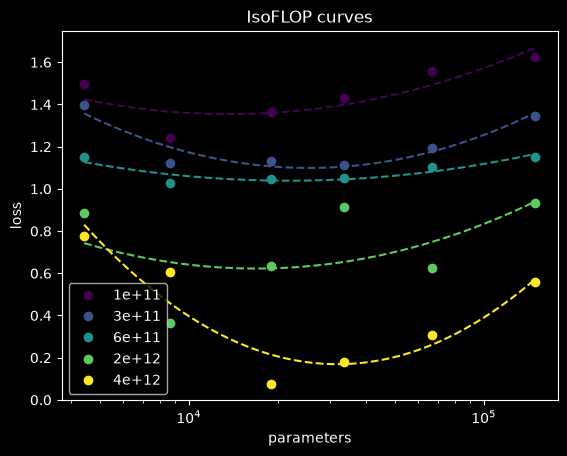

In [11]:
n_opt_power, n_opt_coeff, d_opt_power, d_opt_coeff = fit_power_laws_approach_2(
    MODEL_CONFIGS,
    valid_flop_horizons,
    smoothed_valid_loss_grid,
)

print('Approach 2 results:')
print(f'N_opt power: {n_opt_power}, coeff: {n_opt_coeff}')
print(f'D_opt power: {d_opt_power}, coeff: {d_opt_coeff}')


## Approach 3: Fitting a parametric loss function

In [20]:
import itertools


def fit_power_laws_approach_3(model_configs, valid_training_configs, valid_flop_horizons, smoothed_valid_loss_grid):
    # run L-BFGS algorithm to fit initial loss function
    def run_lbfgs_opt(init_params, f, opt, max_iter, tol):
        value_and_grad_f = optax.value_and_grad_from_state(f)
        def step(carry):
            params, state = carry
            value, grad = value_and_grad_f(params, state=state)
            updates, state = opt.update(
                grad, state, params, value=value, grad=grad, value_fn=f
            )
            params = optax.apply_updates(params, updates)
            return params, state

        # use grad tol for stopping condition
        def continue_criterion(carry):
            _, state = carry
            iter = optax.tree.get(state, 'count')
            grad = optax.tree.get(state, 'grad')
            err = optax.tree.norm(grad)
            return (iter == 0) | ((iter < max_iter) & (err >= tol))

        init_carry = (init_params, opt.init(init_params))
        final_params, _ = jax.lax.while_loop(continue_criterion, step, init_carry)
        return final_params

    ns = []
    ds = []
    ls = []
    for ts_i in range(len(valid_training_configs)):
        for m_i in range(len(model_configs)):
            flops = valid_flop_horizons[ts_i]
            n = model_configs[m_i].size()
            d = flops / (6 * n)
            smoothed_losses = smoothed_valid_loss_grid[ts_i][m_i]
            final_loss = jnp.median(smoothed_losses[-int(0.01*smoothed_losses.shape[0]):])
            ns.append(n)
            ds.append(d)
            ls.append(final_loss)

    ns = jnp.array(ns)
    ds = jnp.array(ds)
    ls = jnp.array(ls)

    # e = params[0], a = params[1], b = params[2], alpha = params[3], beta = params[4]
    # ns: [N, ], ds: [N, ]
    # returns log of loss already
    def log_loss_model(params, ns, ds):
        e, a, b, alpha, beta = params
        # [N, ]
        op1 = a - alpha*jnp.log(ns)
        # [N, ]
        op2 = b - beta*jnp.log(ds)
        e = jnp.broadcast_to(e, ns.shape)
        # [N, ]
        return jax.nn.logsumexp(jnp.vstack([op1, op2, e]), axis=0)

    def fit_loss(params):
        diff = log_loss_model(params, ns, ds) - jnp.log(ls)
        return jnp.sum(optax.huber_loss(diff, delta=1e-3))

    # try grid of initializations for best fit
    alpha_grid = [0, 0.5, 1, 1.5, 2]
    beta_grid = [0, 0.5, 1, 1.5, 2]
    e_grid = [-1, -0.5, 0, 0.5, 1]
    a_grid = [0, 5, 10, 15, 20, 25]
    b_grid = [0, 5, 10, 15, 20, 25]

    init_params_grid = itertools.product(e_grid, a_grid, b_grid, alpha_grid, beta_grid)
    init_params_grid = jnp.vstack([jnp.array(i) for i in init_params_grid])

    def fit_loss_model_from_init_param(init_params):
        opt = optax.lbfgs()
        final_params = run_lbfgs_opt(init_params, fit_loss, opt, max_iter=200, tol=1e-3)
        return final_params, fit_loss(final_params)

    final_params_grid, final_params_losses = jax.vmap(fit_loss_model_from_init_param)(init_params_grid)
    # mask out nans from final loss
    final_params_losses = jnp.where(jnp.isnan(final_params_losses), jnp.float32('inf'), final_params_losses)
    min_loss_i = jnp.argmin(final_params_losses)
    min_loss = final_params_losses[min_loss_i]
    min_params = final_params_grid[min_loss_i]

    e_opt, a_opt, b_opt, alpha_opt, beta_opt = min_params
    A_opt, B_opt, E_opt = jnp.exp(a_opt), jnp.exp(b_opt), jnp.exp(e_opt)
    G = ((alpha_opt * A_opt) / (beta_opt * B_opt)) ** (1/(alpha_opt + beta_opt))
    n_opt_power = beta_opt / (alpha_opt + beta_opt)
    d_opt_power = alpha_opt / (alpha_opt + beta_opt)

    return G, n_opt_power, d_opt_power




In [12]:
G, n_opt_power, d_opt_power = fit_power_laws_approach_3(MODEL_CONFIGS, valid_training_configs, smoothed_valid_loss_grid)

print('Approach 3 results:')
print(f'N_opt power: {n_opt_power}')
print(f'D_opt power: {d_opt_power}')

Approach 3 results:
N_opt power: 0.2554893493652344
D_opt power: 0.7445105910301208


## Chinchilla Laws (MoE version)

In [12]:
MOE_MODEL_CONFIGS = [
    # 4.4K
    ModelConfig(
        hidden_size=16,
        ffw_size=4*16,
        layers=1,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1,
        )
    ),

    # 8K
    ModelConfig(
        hidden_size=16,
        ffw_size=4*16,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    ),

    # ~19K
    ModelConfig(
        hidden_size=24,
        ffw_size=4*24,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    ),

    # 33.6K
    ModelConfig(
        hidden_size=32,
        ffw_size=4*32,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    ),

    # 66.8K
    ModelConfig(
        hidden_size=32,
        ffw_size=4*32,
        layers=4,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    ),

    # ~150K
    ModelConfig(
        hidden_size=48,
        ffw_size=4*48,
        layers=4,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    ),
]

MOE_TRAINING_CONFIGS = build_grid_training_configs(
    MOE_MODEL_CONFIGS,
    FLOP_HORIZONS,
    CHUNK_SIZE,
    BS,
    load_bal_alpha=1e-2
)

model size: 4.42e+03 training for flops: 1.00e+11 and steps: 13880
model size: 8.61e+03 training for flops: 1.00e+11 and steps: 7120
model size: 1.91e+04 training for flops: 1.00e+11 and steps: 3220
model size: 3.36e+04 training for flops: 1.00e+11 and steps: 1830
model size: 6.68e+04 training for flops: 1.00e+11 and steps: 920
model size: 1.49e+05 training for flops: 9.99e+10 and steps: 410
model size: 4.42e+03 training for flops: 2.51e+11 and steps: 34860
model size: 8.61e+03 training for flops: 2.51e+11 and steps: 17880
model size: 1.91e+04 training for flops: 2.51e+11 and steps: 8080
model size: 3.36e+04 training for flops: 2.51e+11 and steps: 4580
model size: 6.68e+04 training for flops: 2.52e+11 and steps: 2310
model size: 1.49e+05 training for flops: 2.53e+11 and steps: 1040
model size: 4.42e+03 training for flops: 6.31e+11 and steps: 87550
model size: 8.61e+03 training for flops: 6.31e+11 and steps: 44920
model size: 1.91e+04 training for flops: 6.31e+11 and steps: 20290
model 

In [ ]:
# compute loss grid from scratch
moe_loss_grid, moe_ce_loss_grid, moe_aux_loss_grid = train_grid(MOE_MODEL_CONFIGS, MOE_TRAINING_CONFIGS, folder='moe_grid')

In [13]:
moe_loss_grid, moe_ce_loss_grid, moe_aux_loss_grid = load_loss_grid_from_disk(MOE_MODEL_CONFIGS, MOE_TRAINING_CONFIGS, folder='moe_grid')

In [15]:
smoothed_moe_ce_loss_grid = smooth_loss_grid(MOE_MODEL_CONFIGS, MOE_TRAINING_CONFIGS, moe_loss_grid)
smoothed_valid_moe_ce_loss_grid, valid_moe_training_configs, valid_moe_flop_horizons = filter_saturated_runs(
    MOE_MODEL_CONFIGS,
    MOE_TRAINING_CONFIGS,
    FLOP_HORIZONS,
    smoothed_moe_ce_loss_grid
)

for f in valid_moe_flop_horizons:
    print(f'VALID FLOP HORIZON: {f:1.2e}')


VALID FLOP HORIZON: 1.00e+11
VALID FLOP HORIZON: 2.51e+11
VALID FLOP HORIZON: 6.31e+11
VALID FLOP HORIZON: 1.58e+12
VALID FLOP HORIZON: 3.98e+12
VALID FLOP HORIZON: 1.00e+13


In [16]:
# approach 1
moe_n_opt_power, moe_n_opt_coeff, moe_d_opt_power, moe_d_opt_coeff = fit_power_laws_approach_1(
    MOE_MODEL_CONFIGS,
    valid_moe_training_configs,
    smoothed_valid_moe_ce_loss_grid,
    350
)

print('Approach 1 results:')
print(f'N_opt power: {moe_n_opt_power}, coeff: {moe_n_opt_coeff}')
print(f'D_opt power: {moe_d_opt_power}, coeff: {moe_d_opt_coeff}')

Approach 1 results:
N_opt power: [0.18182345], coeff: [74.29518091]
D_opt power: [0.81817655], coeff: [0.0022433]


Approach 2 results:
N_opt power: [0.43188701], coeff: [0.15921309]
D_opt power: [0.56812492], coeff: [1.04640024]


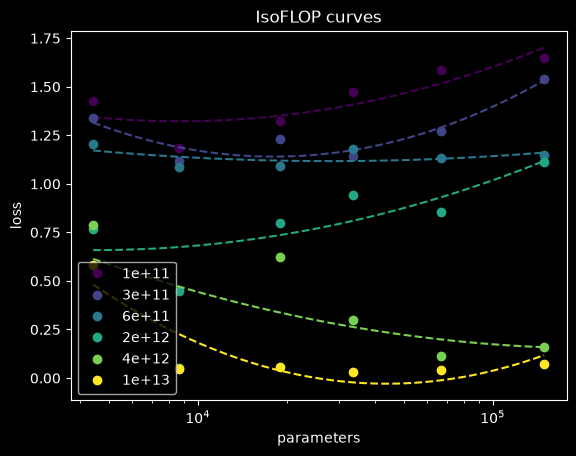

In [17]:
# approach 2
moe_n_opt_power, moe_n_opt_coeff, moe_d_opt_power, moe_d_opt_coeff = fit_power_laws_approach_2(
    MOE_MODEL_CONFIGS,
    valid_moe_flop_horizons,
    smoothed_valid_moe_ce_loss_grid,
)

print('Approach 2 results:')
print(f'N_opt power: {moe_n_opt_power}, coeff: {moe_n_opt_coeff}')
print(f'D_opt power: {moe_d_opt_power}, coeff: {moe_d_opt_coeff}')

In [21]:
# approach 3
moe_G, moe_n_opt_power, moe_d_opt_power = fit_power_laws_approach_3(
    MOE_MODEL_CONFIGS,
    valid_moe_training_configs,
    valid_moe_flop_horizons,
    smoothed_valid_moe_ce_loss_grid
)

print('Approach 3 results:')
print(f'N_opt power: {moe_n_opt_power}')
print(f'D_opt power: {moe_d_opt_power}')

Approach 3 results:
N_opt power: 0.024776151403784752
D_opt power: 0.9752238988876343


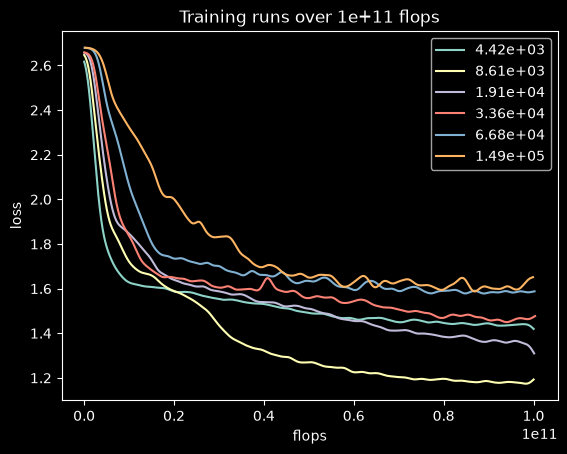

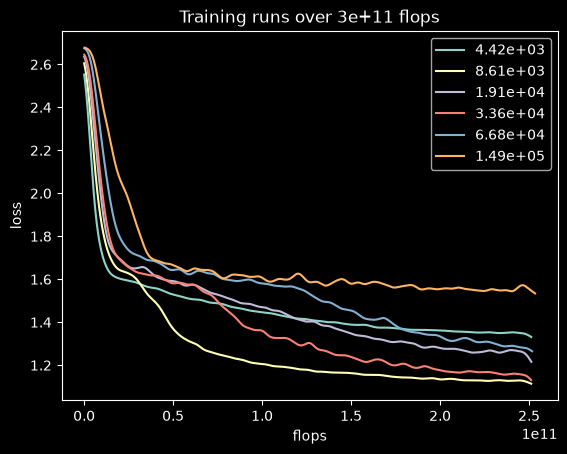

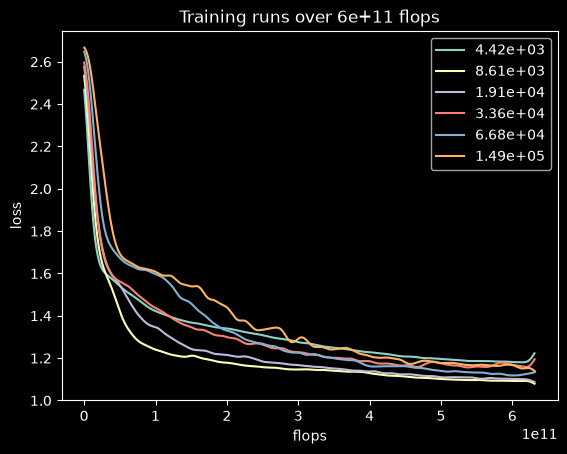

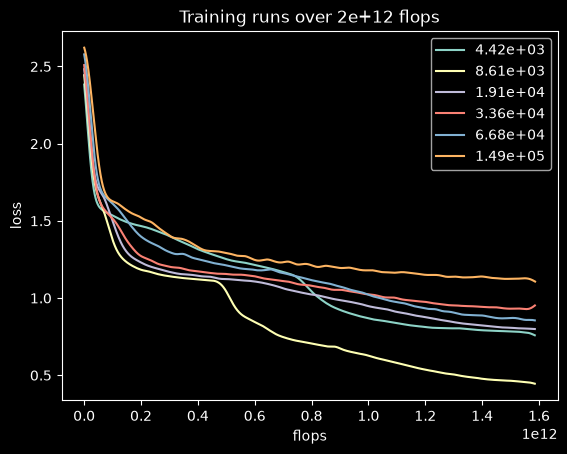

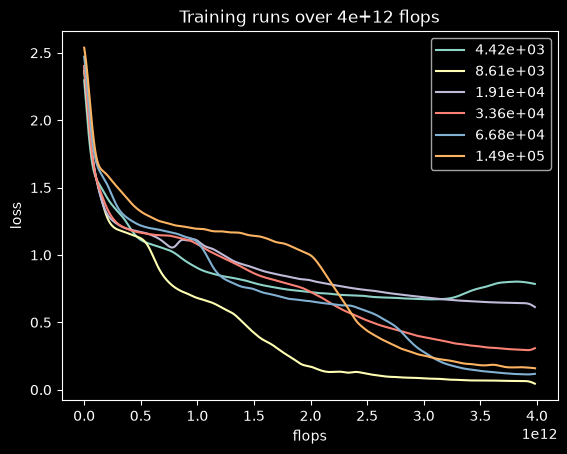

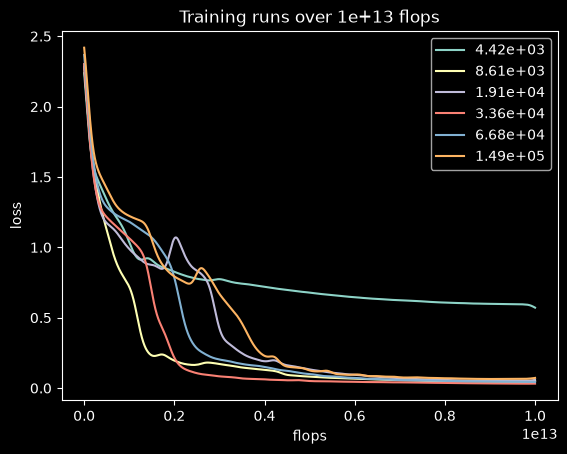

In [22]:
for i in range(len(MOE_TRAINING_CONFIGS)):
    ts = MOE_TRAINING_CONFIGS[i]
    losses = smoothed_valid_moe_loss_grid[i]
    plot_losses(MOE_MODEL_CONFIGS, ts, losses)

## Train 10M param MoE and dense models

In [ ]:
DENSE_10M_MODEL_CONFIG = ModelConfig(
    hidden_size=256,
    ffw_size=4*256,
    layers=10,
    attn_heads=4,
    vocab_size=14,
    moe_config=None
)

MOE_10M_MODEL_CONFIG = ModelConfig(
    hidden_size=224,
    ffw_size=4*224,
    layers=8,
    attn_heads=4,
    vocab_size=14,
    moe_config=MoEConfig(
        experts_per_token=2,
        experts=4
    )
)


bs = 32
chunk_size = 100
steps = 100_000
flops = int(6 * DENSE_10M_MODEL_CONFIG.size() * bs * MAX_SEQ_LEN * steps)
TRAINING_CONFIG_10M = TrainingConfig(
    TrainingConfig(
        max_lr=1e-3,
        min_lr=1e-4,
        steps=steps,
        flops=flops,
        warmup_steps=int(0.1*steps),
        bs=bs,
        seed=42,
        chunk_size=chunk_size,
        print_every=1000,
        load_bal_alpha=1e-2
    )
)

In [ ]:
dense_losses = train_model(DENSE_10M_MODEL_CONFIG, TRAINING_CONFIG_10M)
plot_losses([DENSE_10M_MODEL_CONFIG], [TRAINING_CONFIG_10M], dense_losses, f_name='10M_dense')

In [ ]:
moe_losses, ce_losses, aux_losses = train_model(MOE_10M_MODEL_CONFIG, TRAINING_CONFIG_10M)
plot_losses([MOE_10M_MODEL_CONFIG], [TRAINING_CONFIG_10M], moe_losses, f_name='10M_moe')